
Objective:Build a receipt parser that extracts structured data from receipt images

Model:Donut (Document Understanding Transformer)

Approach:Use pre-trained model, understand architecture, build production-ready parser

- How Vision Transformers process images
- Encoder-Decoder architecture
- Document understanding without traditional OCR

1. Imports & Setup

In [1]:
import os
import json
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# PyTorch
import torch

# Transformers - Donut model
from transformers import DonutProcessor, VisionEncoderDecoderModel

# HuggingFace Datasets - for sample receipts
from datasets import load_dataset

# Settings
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Project root: works whether notebook is run from spendwise-ai/ or spendwise-ai/src/ or Final_Project/
PROJECT_ROOT = Path.cwd()
if (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT / "src").exists():
    pass
elif PROJECT_ROOT.name == "src" and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
elif (PROJECT_ROOT / "spendwise-ai" / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT / "spendwise-ai"
(PROJECT_ROOT / "data" / "processed").mkdir(parents=True, exist_ok=True)


Device: cpu


2. Understanding Donut Architecture
Donut = Document Understanding Transformer

# **Traditional OCR Pipeline:**

# Image → Text Detection → Text Recognition → Post-processing → Output
# (4 separate steps, errors compound)


# **Donut Pipeline:**

# Image → Single End-to-End Model → Structured Output
# (1 step, trained together)

# **Architecture:**
# - **Encoder (Swin Transformer):** Processes image into feature representations
# - **Decoder (BART):** Generates structured text output token by token
#
# The encoder "sees" the receipt, the decoder "writes" the JSON.


3. Load Sample Receipt Dataset (CORD)

In [2]:

# CORD = Consolidated Receipt Dataset
# - 1000 receipt images with annotations
# - Used for training/evaluating document understanding models

print("Loading CORD dataset from HuggingFace...")
dataset = load_dataset("naver-clova-ix/cord-v2")

print(f"\n Dataset loaded!")
print(f"   Train: {len(dataset['train'])} receipts")
print(f"   Validation: {len(dataset['validation'])} receipts")
print(f"   Test: {len(dataset['test'])} receipts")

# Examine one sample
sample = dataset['train'][0]
print(f"\nSample keys: {sample.keys()}")
print(f"Image size: {sample['image'].size}")
print(f"\nGround truth (first 300 chars):")
print(sample['ground_truth'][:300])


Loading CORD dataset from HuggingFace...

 Dataset loaded!
   Train: 800 receipts
   Validation: 100 receipts
   Test: 100 receipts

Sample keys: dict_keys(['image', 'ground_truth'])
Image size: (864, 1296)

Ground truth (first 300 chars):
{"gt_parse": {"menu": [{"nm": "Nasi Campur Bali", "cnt": "1 x", "price": "75,000"}, {"nm": "Bbk Bengil Nasi", "cnt": "1 x", "price": "125,000"}, {"nm": "MilkShake Starwb", "cnt": "1 x", "price": "37,000"}, {"nm": "Ice Lemon Tea", "cnt": "1 x", "price": "24,000"}, {"nm": "Nasi Ayam Dewata", "cnt": "1


4. Visualize Sample Receipts

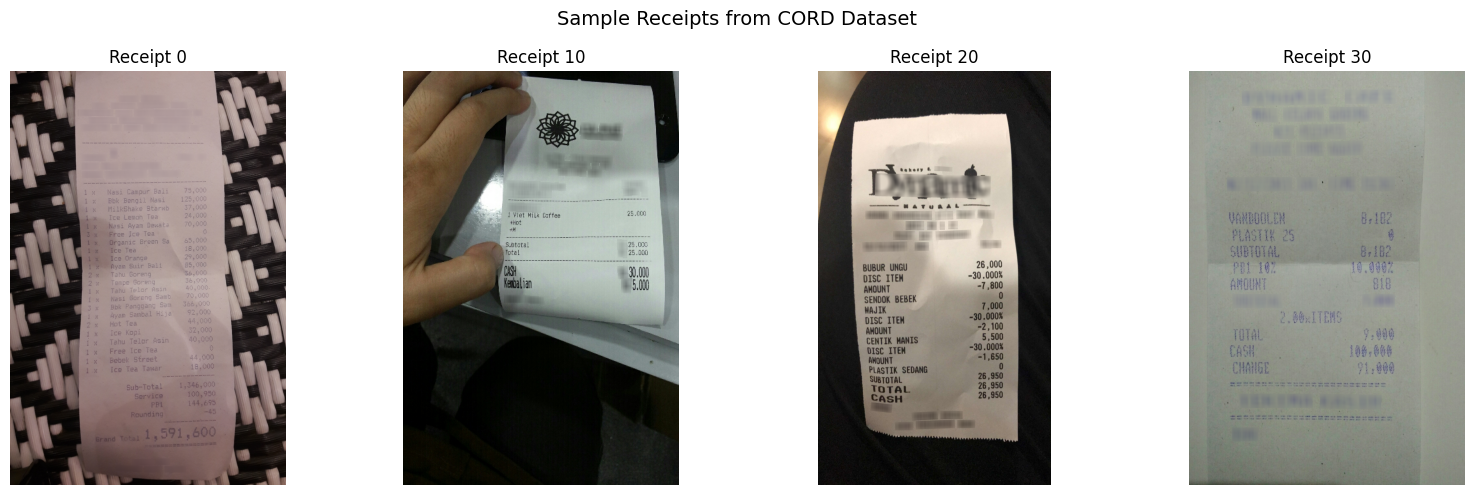

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, idx in enumerate([0, 10, 20, 30]):
    sample = dataset['train'][idx]
    axes[i].imshow(sample['image'])
    axes[i].set_title(f"Receipt {idx}")
    axes[i].axis('off')

plt.suptitle("Sample Receipts from CORD Dataset", fontsize=14)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data/processed/receipt_samples.png", dpi=150, bbox_inches='tight')
plt.show()


5. Load Pre-trained Donut Model

In [4]:

# We use `donut-base-finetuned-cord-v2`:
# - Pre-trained on document images
# - Fine-tuned on CORD receipt dataset
# - Ready to use for receipt parsing

MODEL_NAME = "naver-clova-ix/donut-base-finetuned-cord-v2"

print(f"Loading Donut model: {MODEL_NAME}")
print("   (This may take a minute on first download...)\n")

# Processor: handles image preprocessing + tokenization
processor = DonutProcessor.from_pretrained(MODEL_NAME)

# Model: the actual neural network
model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)
model.to(device)
model.eval()  # Set to evaluation mode (no training)

print(f" Model loaded on {device}")
print(f"   Total parameters: {sum(p.numel() for p in model.parameters()):,}")


Loading Donut model: naver-clova-ix/donut-base-finetuned-cord-v2
   (This may take a minute on first download...)



The image processor of type `DonutImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


 Model loaded on cpu
   Total parameters: 260,083,832


6. Understanding the Model Components

In [5]:
# Let's examine what's inside Donut:


print("Model Architecture:\n")

# Encoder (Vision)
print("ENCODER (Swin Transformer):")
print(f"   - Processes image into {model.encoder.config.hidden_size}-dim features")
print(f"   - Image is split into patches and processed with attention")

# Decoder (Text)  
print(f"\nDECODER (BART):")
print(f"   - Vocabulary size: {model.decoder.config.vocab_size:,} tokens")
print(f"   - Hidden size: {model.decoder.config.hidden_size}")
print(f"   - Generates output token by token")

print(f"\nFlow: Image → Encoder → Features → Decoder → JSON tokens")


Model Architecture:

ENCODER (Swin Transformer):
   - Processes image into 1024-dim features
   - Image is split into patches and processed with attention

DECODER (BART):
   - Vocabulary size: 57,580 tokens
   - Hidden size: 1024
   - Generates output token by token

Flow: Image → Encoder → Features → Decoder → JSON tokens


7. Process a Single Receipt

In [6]:

# Let's trace through exactly how one receipt gets processed:

# Get a test receipt
test_image = dataset['test'][0]['image']

print("Step 1: Preprocess image")
print(f"   Original size: {test_image.size}")

# Processor converts image to tensor
pixel_values = processor(test_image, return_tensors="pt").pixel_values
pixel_values = pixel_values.to(device)

print(f"   Tensor shape: {pixel_values.shape}")
print(f"   (batch=1, channels=3, height=960, width=720)")


print("\nStep 2: Create decoder prompt")

# Donut uses a task prompt to know what to extract
task_prompt = "<s_cord-v2>"  # Special token for CORD format

decoder_input_ids = processor.tokenizer(
    task_prompt,
    add_special_tokens=False,
    return_tensors="pt"
).input_ids.to(device)

print(f"   Prompt: '{task_prompt}'")
print(f"   Token IDs: {decoder_input_ids}")


print("\nStep 3: Generate output (this is where the magic happens)")

with torch.no_grad():  # No gradient calculation needed for inference
    outputs = model.generate(
        pixel_values,                    # Image features
        decoder_input_ids=decoder_input_ids,  # Starting prompt
        max_length=512,                  # Maximum output length
        early_stopping=True,             # Stop at end token
        num_beams=4,                     # Beam search for better results
        pad_token_id=processor.tokenizer.pad_token_id,
        eos_token_id=processor.tokenizer.eos_token_id,
    )

print(f"   Output shape: {outputs.shape}")
print(f"   Generated {outputs.shape[1]} tokens")


print("\nStep 4: Decode tokens to text")

# Convert token IDs back to text
sequence = processor.batch_decode(outputs)[0]
print(f"   Raw output (first 200 chars):")
print(f"   {sequence[:200]}...")


print("\nStep 5: Parse to structured JSON")

# Clean up special tokens
sequence = sequence.replace(processor.tokenizer.eos_token, "")
sequence = sequence.replace(processor.tokenizer.pad_token, "")

# Donut has a built-in token-to-JSON converter
result = processor.token2json(sequence)

print("   Parsed result:")
print(json.dumps(result, indent=2)[:500])


Step 1: Preprocess image
   Original size: (432, 648)
   Tensor shape: torch.Size([1, 3, 1280, 960])
   (batch=1, channels=3, height=960, width=720)

Step 2: Create decoder prompt
   Prompt: '<s_cord-v2>'
   Token IDs: tensor([[57579]])

Step 3: Generate output (this is where the magic happens)
   Output shape: torch.Size([1, 54])
   Generated 54 tokens

Step 4: Decode tokens to text
   Raw output (first 200 chars):
   <s_cord-v2><s_menu><s_nm> - TICKET CP</s_nm><s_num> 901016</s_num><s_unitprice> 60.000</s_unitprice><s_cnt> 2</s_cnt><s_price> 60.000</s_price></s_menu><s_sub_total><s_subtotal_price> -60.000</s_subto...

Step 5: Parse to structured JSON
   Parsed result:
{
  "menu": {
    "nm": "- TICKET CP",
    "num": "901016",
    "unitprice": "60.000",
    "cnt": "2",
    "price": "60.000"
  },
  "sub_total": {
    "subtotal_price": "-60.000",
    "tax_price": "5,455"
  },
  "total": {
    "total_price": "60.000",
    "emoneyprice": "60.000",
    "menuqty_cnt": "2.00"
  }
}


8. Visualize Extraction Result

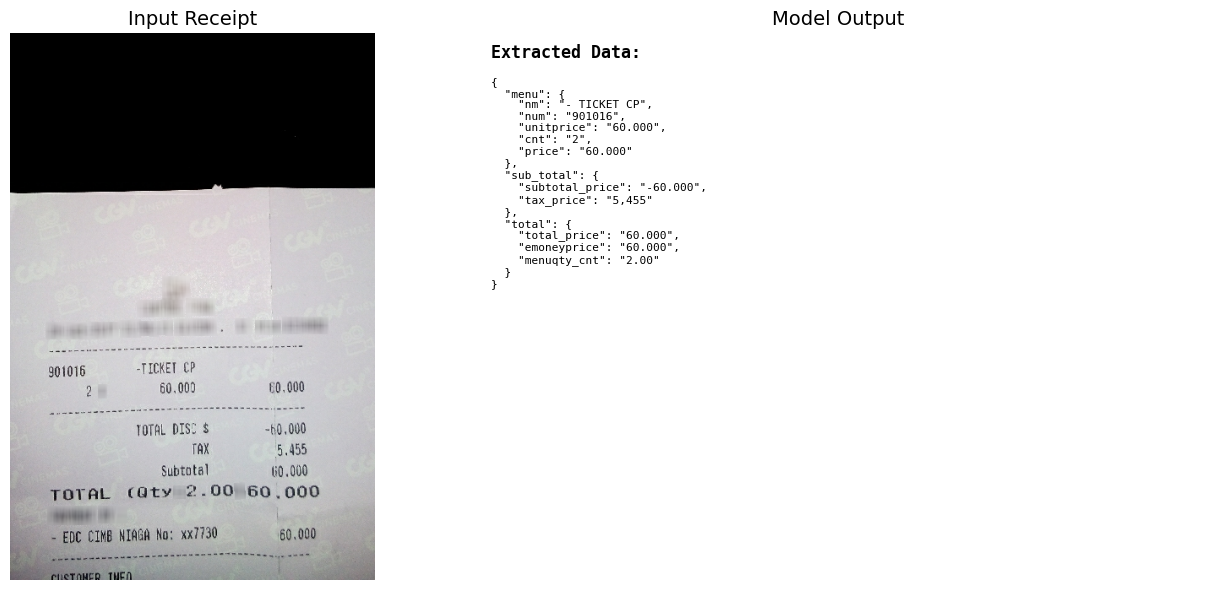

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Show original image
axes[0].imshow(test_image)
axes[0].set_title("Input Receipt", fontsize=14)
axes[0].axis('off')

# Show extracted data
result_text = json.dumps(result, indent=2)
if len(result_text) > 800:
    result_text = result_text[:800] + "\n..."
    
axes[1].text(0.02, 0.98, "Extracted Data:", fontsize=12, fontweight='bold',
             transform=axes[1].transAxes, verticalalignment='top', family='monospace')
axes[1].text(0.02, 0.92, result_text, fontsize=8, 
             transform=axes[1].transAxes, verticalalignment='top', family='monospace')
axes[1].axis('off')
axes[1].set_title("Model Output", fontsize=14)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data/processed/receipt_extraction_demo.png", dpi=150, bbox_inches='tight')
plt.show()


9. Build Production-Ready ReceiptParser Class

In [8]:
# Encapsulate everything into a clean, reusable class:

class ReceiptParser:
    """
    Production-ready receipt parser using Donut
    
    Usage:
        parser = ReceiptParser()
        result = parser.parse("receipt.jpg")
    """
    
    def __init__(self, model_name: str = "naver-clova-ix/donut-base-finetuned-cord-v2"):
        """Initialize parser with pre-trained model"""
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        # Load model and processor
        self.processor = DonutProcessor.from_pretrained(model_name)
        self.model = VisionEncoderDecoderModel.from_pretrained(model_name)
        self.model.to(self.device)
        self.model.eval()
        
        # Task prompt for CORD format
        self.task_prompt = "<s_cord-v2>"
    
    def parse(self, image) -> dict:
        """
        Parse a receipt image and extract structured data
        
        Args:
            image: PIL Image, file path, or numpy array
            
        Returns:
            dict with extracted receipt information
        """
        # Handle different input types
        if isinstance(image, str):
            image = Image.open(image).convert('RGB')
        elif isinstance(image, np.ndarray):
            image = Image.fromarray(image).convert('RGB')
        
        # Preprocess
        pixel_values = self.processor(image, return_tensors="pt").pixel_values
        pixel_values = pixel_values.to(self.device)
        
        # Prepare decoder input
        decoder_input_ids = self.processor.tokenizer(
            self.task_prompt,
            add_special_tokens=False,
            return_tensors="pt"
        ).input_ids.to(self.device)
        
        # Generate
        with torch.no_grad():
            outputs = self.model.generate(
                pixel_values,
                decoder_input_ids=decoder_input_ids,
                max_length=512,
                early_stopping=True,
                num_beams=4,
                pad_token_id=self.processor.tokenizer.pad_token_id,
                eos_token_id=self.processor.tokenizer.eos_token_id,
            )
        
        # Decode and parse
        sequence = self.processor.batch_decode(outputs)[0]
        sequence = sequence.replace(self.processor.tokenizer.eos_token, "")
        sequence = sequence.replace(self.processor.tokenizer.pad_token, "")
        
        raw_result = self.processor.token2json(sequence)
        
        # Post-process into cleaner format
        return self._post_process(raw_result)
    
    def _post_process(self, raw: dict) -> dict:
        """Convert raw Donut output to cleaner format"""
        
        result = {
            "items": [],
            "subtotal": None,
            "tax": None,
            "total": None,
            "raw": raw  # Keep original for debugging
        }
        
        # Extract menu items
        if 'menu' in raw:
            for item in raw.get('menu', []):
                if isinstance(item, dict):
                    result["items"].append({
                        "name": item.get('nm', ''),
                        "quantity": self._parse_int(item.get('cnt', '1')),
                        "price": self._parse_float(item.get('price', '0')),
                    })
                elif isinstance(item, str) and item.strip():
                    result["items"].append({
                        "name": item.strip(),
                        "quantity": 1,
                        "price": 0.0,
                    })
        
        # Extract totals
        if 'total' in raw:
            total_info = raw['total']
            if isinstance(total_info, dict):
                result["subtotal"] = self._parse_float(total_info.get('subtotal_price'))
                result["tax"] = self._parse_float(total_info.get('tax_price'))
                result["total"] = self._parse_float(total_info.get('total_price'))
        
        return result
    
    def _parse_float(self, value) -> float:
        """Safely parse price string to float"""
        if not value:
            return 0.0
        try:
            cleaned = ''.join(c for c in str(value) if c.isdigit() or c == '.')
            return float(cleaned) if cleaned else 0.0
        except:
            return 0.0
    
    def _parse_int(self, value) -> int:
        """Safely parse quantity string to int"""
        try:
            cleaned = ''.join(c for c in str(value) if c.isdigit())
            return int(cleaned) if cleaned else 1
        except:
            return 1


10. Test the Parser on Multiple Receipts

In [9]:


print("🔧 Initializing ReceiptParser...")
parser = ReceiptParser()
print("Parser ready!\n")

# Test on multiple receipts
print("Testing on 5 sample receipts:\n")
print("=" * 60)

for i in [0, 5, 10, 15, 20]:
    sample = dataset['test'][i]
    result = parser.parse(sample['image'])
    
    print(f"\nReceipt {i}:")
    print(f"   Items found: {len(result['items'])}")
    if result['total']:
        print(f"   Total: ${result['total']:.2f}")
    
    # Show first 3 items
    for item in result['items'][:3]:
        print(f"   • {item['name']}: ${item['price']:.2f}")


🔧 Initializing ReceiptParser...


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Parser ready!

Testing on 5 sample receipts:


Receipt 0:
   Items found: 5
   Total: $60.00
   • nm: $0.00
   • num: $0.00
   • unitprice: $0.00

Receipt 5:
   Items found: 2
   Total: $31.00
   • nm: $0.00
   • price: $0.00

Receipt 10:
   Items found: 4
   Total: $17000.00
   • nm: $0.00
   • unitprice: $0.00
   • cnt: $0.00

Receipt 15:
   Items found: 2
   Total: $63.00
   • Lemon Tea (L): $25.00
   • Caramel Small: $38.00

Receipt 20:
   Items found: 5
   Total: $377859.00
   • cashew nuts chkn: $64500.00
   • garlic pepper beef: $79500.00
   • red curry beef: $69500.00


11. Measure Performance

In [10]:


import time

def evaluate_parser(parser, dataset, n_samples: int = 30):
    """Evaluate parser speed and detection rate"""
    
    times = []
    items_detected = []
    
    for i in tqdm(range(min(n_samples, len(dataset))), desc="Evaluating"):
        sample = dataset[i]
        
        # Time the parsing
        start = time.time()
        result = parser.parse(sample['image'])
        elapsed = time.time() - start
        
        times.append(elapsed)
        items_detected.append(len(result['items']))
    
    return {
        "avg_time": np.mean(times),
        "min_time": np.min(times),
        "max_time": np.max(times),
        "avg_items": np.mean(items_detected),
        "samples": n_samples
    }


print("Evaluating parser performance...")
metrics = evaluate_parser(parser, dataset['test'], n_samples=30)

print(f"\nEvaluation Results:")
print(f"   Average processing time: {metrics['avg_time']:.2f}s per receipt")
print(f"   Time range: {metrics['min_time']:.2f}s - {metrics['max_time']:.2f}s")
print(f"   Average items detected: {metrics['avg_items']:.1f} per receipt")


Evaluating parser performance...


Evaluating: 100%|██████████| 30/30 [00:56<00:00,  1.87s/it]


Evaluation Results:
   Average processing time: 1.85s per receipt
   Time range: 1.23s - 3.46s
   Average items detected: 3.2 per receipt


12. Save Parser Module for Production


In [11]:


# Save the ReceiptParser class as a Python module
parser_code = '''"""
Receipt Parser Module - SpendWise AI

Uses Donut (Document Understanding Transformer) for receipt parsing.
"""

import torch
import numpy as np
from PIL import Image
from transformers import DonutProcessor, VisionEncoderDecoderModel


class ReceiptParser:
    """Production-ready receipt parser using Donut"""
    
    def __init__(self, model_name: str = "naver-clova-ix/donut-base-finetuned-cord-v2"):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.processor = DonutProcessor.from_pretrained(model_name)
        self.model = VisionEncoderDecoderModel.from_pretrained(model_name)
        self.model.to(self.device)
        self.model.eval()
        self.task_prompt = "<s_cord-v2>"
    
    def parse(self, image) -> dict:
        """Parse receipt image to structured data"""
        if isinstance(image, str):
            image = Image.open(image).convert('RGB')
        elif isinstance(image, np.ndarray):
            image = Image.fromarray(image).convert('RGB')
        
        pixel_values = self.processor(image, return_tensors="pt").pixel_values.to(self.device)
        decoder_input_ids = self.processor.tokenizer(
            self.task_prompt, add_special_tokens=False, return_tensors="pt"
        ).input_ids.to(self.device)
        
        with torch.no_grad():
            outputs = self.model.generate(
                pixel_values, decoder_input_ids=decoder_input_ids,
                max_length=512, early_stopping=True, num_beams=4,
                pad_token_id=self.processor.tokenizer.pad_token_id,
                eos_token_id=self.processor.tokenizer.eos_token_id,
            )
        
        sequence = self.processor.batch_decode(outputs)[0]
        sequence = sequence.replace(self.processor.tokenizer.eos_token, "")
        sequence = sequence.replace(self.processor.tokenizer.pad_token, "")
        
        return self.processor.token2json(sequence)
'''

# Save to src folder
src_path = PROJECT_ROOT / "src" / "receipt_parser.py"
with open(src_path, 'w') as f:
    f.write(parser_code)

print(f"Parser module saved to: {src_path}")


Parser module saved to: /Users/patel/Documents/E/MPS Sem 5/EAI 6020/Final_Project/spendwise-ai/src/receipt_parser.py
